# Phase 2 — Segmentation via Clustering

**Home Credit Default Risk** · KDD Phase 2

## Tujuan
1. Reduksi dimensi dengan **PCA** untuk mengatasi curse of dimensionality
2. Tentukan **K optimal** via Elbow Method + Silhouette Score
3. Terapkan tiga algoritma: **K-Means**, **DBSCAN**, **Hierarchical** (BIRCH micro-clusters + Agglomerative)
4. Profile setiap cluster + tetapkan nama bisnis + tulis business report

## Input
- `datasets/final/features_clustering.csv` (output Phase 1)

## Output → `results/phase2_clustering/`
- `pca_variance.csv`, `pca_variance_plot.png`
- `k_selection.csv`, `elbow_plot.png`, `silhouette_plot.png`
- `cluster_labels.csv`, `cluster_viz.png`, `dendrogram.png`
- `cluster_profiles.csv`, `cluster_summary.csv`, `cluster_profile_plot.png`
- `business_report.txt`

## 1. Setup & Load Data

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, Birch, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
INPUT_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
OUT_DIR = PROJECT_ROOT / 'results/phase2_clustering'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
K_OPTIMAL = 5
N_PCA_CLUSTER = 10

print(f'Project root: {PROJECT_ROOT}')
print(f'Output dir  : {OUT_DIR}')

df = pd.read_csv(INPUT_PATH)
print(f'\nLoaded features_clustering: {df.shape[0]:,} rows × {df.shape[1]:,} cols')
df.head()

Project root: C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk
Output dir  : C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering



Loaded features_clustering: 331,219 rows × 67 cols


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,CREDIT_TERM_MONTHS,YEARS_BIRTH,YEARS_EMPLOYED,FLAG_SENTINEL_EMPLOYED,CNT_CHILDREN,...,ORGANIZATION_TYPE_Industry,ORGANIZATION_TYPE_Other,ORGANIZATION_TYPE_Private_Business,ORGANIZATION_TYPE_Security,ORGANIZATION_TYPE_Self_Employed,ORGANIZATION_TYPE_Services,ORGANIZATION_TYPE_Trade,ORGANIZATION_TYPE_Transport,ORGANIZATION_TYPE_Unknown,ORGANIZATION_TYPE_Utilities
0,0.634910,-0.187374,0.066332,-0.701787,-0.629424,-0.583748,-1.509648,-0.574687,0,-0.576864,...,0,0,1,0,0,0,0,0,0,0
1,1.236695,1.428692,0.738721,0.355520,-0.521112,1.956267,0.166044,-0.335664,0,-0.576864,...,0,0,0,0,0,0,0,0,0,0
2,-1.663200,-1.726999,-2.302035,-0.704785,-0.861917,-0.129145,0.689353,-0.753412,0,-0.576864,...,0,0,0,0,0,0,0,0,0,0
3,-0.213256,-0.554125,0.402026,-0.584662,0.406449,-1.345289,0.679947,0.467295,0,-0.576864,...,0,0,1,0,0,0,0,0,0,0
4,-0.433653,0.137228,-0.156247,0.139516,-0.016026,0.315530,0.892620,0.466862,0,-0.576864,...,0,0,0,0,0,1,0,0,0,0


## 2. PCA — Dimensionality Reduction

**Mengapa PCA?** Distance metric Euclidean menjadi tidak akurat di dimensi tinggi (curse of dimensionality). PCA mengkompresi informasi ke komponen yang berkontribusi terbesar terhadap variansi data.

In [2]:
feature_cols = [c for c in df.columns if c != 'SK_ID_CURR']
X = df[feature_cols].values.astype(np.float32)
print(f'Feature matrix X: {X.shape}')

pca_full = PCA(n_components=min(50, X.shape[1]), random_state=RANDOM_SEED)
X_pca50 = pca_full.fit_transform(X)

cumvar = pca_full.explained_variance_ratio_.cumsum()
n_90 = int(np.argmax(cumvar >= 0.90)) + 1
n_80 = int(np.argmax(cumvar >= 0.80)) + 1
print(f'\nKomponen untuk 80% variance: {n_80}')
print(f'Komponen untuk 90% variance: {n_90}')
print(f'\nDigunakan untuk clustering: PC1–PC{N_PCA_CLUSTER} ({cumvar[N_PCA_CLUSTER-1]*100:.1f}% variance)')

X_cluster = X_pca50[:, :N_PCA_CLUSTER]
X_2d = X_pca50[:, :2]

variance_df = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
    'cumulative_variance': cumvar,
})
variance_df.to_csv(OUT_DIR / 'pca_variance.csv', index=False)
print(f'\nSaved {OUT_DIR / "pca_variance.csv"}')

Feature matrix X: (331219, 67)



Komponen untuk 80% variance: 21
Komponen untuk 90% variance: 28

Digunakan untuk clustering: PC1–PC10 (54.4% variance)

Saved C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering\pca_variance.csv


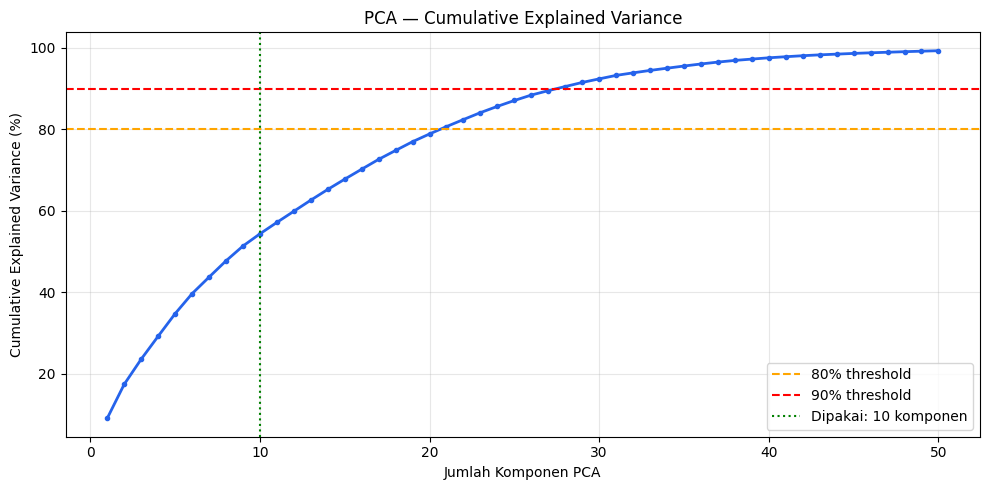

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar*100, marker='o', markersize=3, linewidth=2, color='#2563EB')
ax.axhline(80, color='orange', ls='--', label='80% threshold')
ax.axhline(90, color='red', ls='--', label='90% threshold')
ax.axvline(N_PCA_CLUSTER, color='green', ls=':', label=f'Dipakai: {N_PCA_CLUSTER} komponen')
ax.set_xlabel('Jumlah Komponen PCA')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'pca_variance_plot.png', dpi=150)
plt.show()

## 3. Elbow Method + Silhouette Score → K Optimal

Mencoba K = 2 sampai 10 pada **sample 30K** (silhouette score O(n²) — terlalu mahal untuk full data).

- **Elbow**: cari titik di mana penurunan inertia mulai melandai.
- **Silhouette**: makin tinggi = cluster makin terpisah; rentang [-1, 1].

In [4]:
K_RANGE = range(2, 11)
SAMPLE_SIZE = 30000
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(X_cluster), size=SAMPLE_SIZE, replace=False)
X_sample = X_cluster[sample_idx]

k_results = []
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=RANDOM_SEED)
    k_results.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil, 'time_s': round(time.time()-t0, 2)})
    print(f'  K={k:2d} | inertia={km.inertia_:12.1f} | silhouette={sil:.4f} | {time.time()-t0:.1f}s')

k_df = pd.DataFrame(k_results)
k_df.to_csv(OUT_DIR / 'k_selection.csv', index=False)
k_df

  K= 2 | inertia=    567304.5 | silhouette=0.2611 | 2.8s


  K= 3 | inertia=    511831.5 | silhouette=0.1372 | 0.7s


  K= 4 | inertia=    478276.7 | silhouette=0.1308 | 0.7s


  K= 5 | inertia=    440360.5 | silhouette=0.1444 | 1.0s


  K= 6 | inertia=    417586.4 | silhouette=0.1275 | 1.1s


  K= 7 | inertia=    399069.6 | silhouette=0.1216 | 1.2s


  K= 8 | inertia=    367851.9 | silhouette=0.1234 | 1.4s


  K= 9 | inertia=    355685.8 | silhouette=0.1191 | 1.6s


  K=10 | inertia=    339245.3 | silhouette=0.1212 | 1.5s


,k,inertia,silhouette,time_s
0,2,567304.50000,0.261132,2.83
1,3,511831.53125,0.137230,0.67
2,4,478276.71875,0.130772,0.68
3,5,440360.50000,0.144367,1.04
4,6,417586.43750,0.127470,1.05
5,7,399069.62500,0.121633,1.18
6,8,367851.93750,0.123380,1.43
7,9,355685.78125,0.119052,1.60
8,10,339245.31250,0.121150,1.51


Elbow Method     → K = 5
Silhouette Score → K = 2

Keputusan: K = 5
  Alasan: Elbow merekomendasi 5; silhouette puncak di 2 (biasanya K=2)
  K=5 dipilih karena memberi segmentasi business yang lebih granular & interpretabel.


C:\Users\mario\AppData\Local\Temp\claude\ipykernel_23684\1124794091.py:4: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dists = [np.abs(np.cross(p2-p1, p1-np.array([i, v])))/np.linalg.norm(p2-p1) for i, v in enumerate(inertias)]


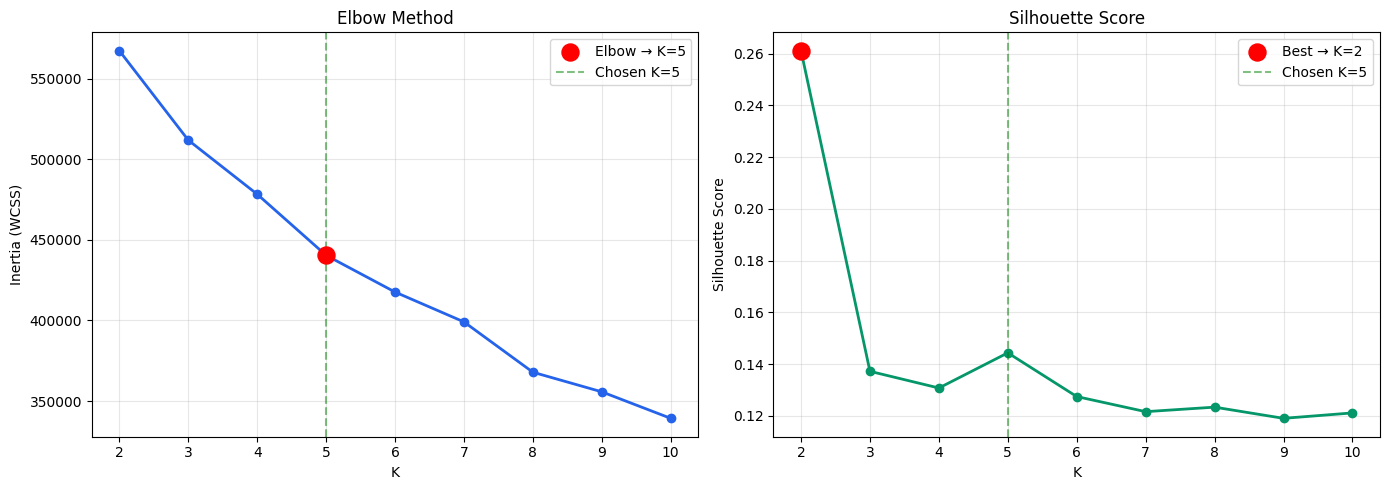

In [5]:
inertias = k_df['inertia'].values
p1 = np.array([0, inertias[0]])
p2 = np.array([len(inertias)-1, inertias[-1]])
dists = [np.abs(np.cross(p2-p1, p1-np.array([i, v])))/np.linalg.norm(p2-p1) for i, v in enumerate(inertias)]
elbow_k = int(k_df.iloc[int(np.argmax(dists))]['k'])
best_sil_k = int(k_df.loc[k_df['silhouette'].idxmax(), 'k'])
print(f'Elbow Method     → K = {elbow_k}')
print(f'Silhouette Score → K = {best_sil_k}')
print(f'\nKeputusan: K = {K_OPTIMAL}')
print(f'  Alasan: Elbow merekomendasi {elbow_k}; silhouette puncak di {best_sil_k} (biasanya K=2)')
print(f'  K=5 dipilih karena memberi segmentasi business yang lebih granular & interpretabel.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_df['k'], k_df['inertia'], 'o-', color='#2563EB', linewidth=2)
axes[0].scatter([elbow_k], [k_df[k_df['k']==elbow_k]['inertia'].values[0]], s=150, color='red', zorder=5, label=f'Elbow → K={elbow_k}')
axes[0].axvline(K_OPTIMAL, color='green', ls='--', alpha=0.5, label=f'Chosen K={K_OPTIMAL}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(k_df['k'], k_df['silhouette'], 'o-', color='#059669', linewidth=2)
axes[1].scatter([best_sil_k], [k_df[k_df['k']==best_sil_k]['silhouette'].values[0]], s=150, color='red', zorder=5, label=f'Best → K={best_sil_k}')
axes[1].axvline(K_OPTIMAL, color='green', ls='--', alpha=0.5, label=f'Chosen K={K_OPTIMAL}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'elbow_plot.png', dpi=150)
plt.show()

## 4. K-Means Clustering (K=5) pada SELURUH 356K data

In [6]:
print('Running K-Means (K=5) on full data ...')
t0 = time.time()
kmeans = KMeans(n_clusters=K_OPTIMAL, n_init=10, max_iter=300, random_state=RANDOM_SEED)
kmeans_labels = kmeans.fit_predict(X_cluster)
print(f'  Done in {time.time()-t0:.1f}s | Inertia = {kmeans.inertia_:.1f}')

rng2 = np.random.default_rng(RANDOM_SEED)
sil_idx = rng2.choice(len(X_cluster), size=10000, replace=False)
sil_kmeans = silhouette_score(X_cluster[sil_idx], kmeans_labels[sil_idx])
print(f'  Silhouette Score (sample 10K): {sil_kmeans:.4f}')

unique, counts = np.unique(kmeans_labels, return_counts=True)
print(f'\nDistribusi cluster K-Means:')
for cid, cnt in zip(unique, counts):
    pct = cnt/len(kmeans_labels)*100
    print(f'  Cluster {cid}: {cnt:>7,} rows ({pct:5.1f}%) {"█"*int(pct/2)}')

Running K-Means (K=5) on full data ...


  Done in 3.8s | Inertia = 4788055.5


  Silhouette Score (sample 10K): 0.1492

Distribusi cluster K-Means:
  Cluster 0:  44,102 rows ( 13.3%) ██████
  Cluster 1: 116,056 rows ( 35.0%) █████████████████
  Cluster 2: 117,406 rows ( 35.4%) █████████████████
  Cluster 3:  50,264 rows ( 15.2%) ███████
  Cluster 4:   3,391 rows (  1.0%) 


## 5. DBSCAN — Deteksi Outlier

DBSCAN O(n²) untuk indexed neighborhood — dijalankan pada sample 30K untuk identifikasi profil outlier (bukan untuk segmentasi semua data). `eps` = radius neighborhood; `min_samples` = density threshold.

In [7]:
DBSCAN_SAMPLE = 30000
EPS = 3.0
MIN_SAMPLES = 10

rng3 = np.random.default_rng(RANDOM_SEED)
dbscan_idx = rng3.choice(len(X_cluster), size=DBSCAN_SAMPLE, replace=False)
X_db = X_cluster[dbscan_idx]

print(f'Running DBSCAN on sample {DBSCAN_SAMPLE:,} (eps={EPS}, min_samples={MIN_SAMPLES}) ...')
t0 = time.time()
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_db)
print(f'  Done in {time.time()-t0:.1f}s')

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = int(np.sum(dbscan_labels == -1))
pct_out = n_outliers/len(dbscan_labels)*100
print(f'  Cluster ditemukan: {n_clusters_db}')
print(f'  Outlier (label -1): {n_outliers:,} ({pct_out:.1f}%)')

u_db, c_db = np.unique(dbscan_labels, return_counts=True)
for lbl, cnt in zip(u_db, c_db):
    name = 'OUTLIER/NOISE' if lbl == -1 else f'Cluster {lbl}'
    pct = cnt/len(dbscan_labels)*100
    print(f'  {name:20s}: {cnt:>6,} ({pct:5.1f}%)')

Running DBSCAN on sample 30,000 (eps=3.0, min_samples=10) ...


  Done in 8.1s
  Cluster ditemukan: 1
  Outlier (label -1): 570 (1.9%)
  OUTLIER/NOISE       :    570 (  1.9%)
  Cluster 0           : 29,430 ( 98.1%)


## 6. Hierarchical Clustering — BIRCH Micro-clusters + Agglomerative

Standar `AgglomerativeClustering` butuh O(n²) memori → mustahil untuk 356K baris (~500 GB).

**Strategi**: BIRCH membangun ratusan micro-cluster centroids → Agglomerative (ward) hierarchical pada centroids → assign label kembali ke semua data. Algoritma intinya tetap hierarchical clustering.

In [8]:
from sklearn.cluster import MiniBatchKMeans

BIRCH_THRESHOLD = 1.5
BIRCH_BRANCHING = 50
BATCH = 20000
MAX_MICRO = 500   # cap for linkage/agglomerative (O(n²) memory)

print(f'Phase 1 — BIRCH partial_fit (threshold={BIRCH_THRESHOLD}) ...')
t0 = time.time()
birch = Birch(threshold=BIRCH_THRESHOLD, branching_factor=BIRCH_BRANCHING, n_clusters=None)
for s in range(0, len(X_cluster), BATCH):
    birch.partial_fit(X_cluster[s:s+BATCH])
raw_subcenters = birch.subcluster_centers_
print(f'  Done in {time.time()-t0:.1f}s | {len(raw_subcenters)} raw BIRCH subclusters')

# Consolidate to <= MAX_MICRO micro-centroids using MiniBatchKMeans on the subcenters
if len(raw_subcenters) > MAX_MICRO:
    print(f'\nConsolidating {len(raw_subcenters)} -> {MAX_MICRO} micro-centroids via MiniBatchKMeans ...')
    t0 = time.time()
    mbk = MiniBatchKMeans(n_clusters=MAX_MICRO, random_state=RANDOM_SEED, n_init=5, batch_size=1024)
    mbk.fit(raw_subcenters)
    subcenters = mbk.cluster_centers_
    raw_to_micro = mbk.labels_   # raw subcluster idx -> micro idx
    print(f'  Done in {time.time()-t0:.1f}s | {len(subcenters)} micro-clusters')
else:
    subcenters = raw_subcenters
    raw_to_micro = np.arange(len(raw_subcenters))

print(f'\nPhase 2 - Linkage (ward, complete, average) on {len(subcenters)} centroids ...')
linkage_methods = ['ward', 'complete', 'average']
linkage_results = {}
for method in linkage_methods:
    t0 = time.time()
    linkage_results[method] = linkage(subcenters, method=method)
    print(f'  {method:8s}: {time.time()-t0:.1f}s')

print('\nPhase 3 - Agglomerative (ward) -> assign labels back to full data ...')
t0 = time.time()
agglo = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
micro_to_cluster = agglo.fit_predict(subcenters)
# Compose: raw_subcluster -> micro -> final_cluster
raw_to_cluster = micro_to_cluster[raw_to_micro]
hier_labels = np.empty(len(X_cluster), dtype=np.int32)
for s in range(0, len(X_cluster), BATCH):
    raw_ids = birch.predict(X_cluster[s:s+BATCH])
    hier_labels[s:s+BATCH] = raw_to_cluster[raw_ids]
print(f'  Done in {time.time()-t0:.1f}s')

u_h, c_h = np.unique(hier_labels, return_counts=True)
print(f'\nDistribusi cluster Hierarchical:')
for cid, cnt in zip(u_h, c_h):
    pct = cnt/len(hier_labels)*100
    print(f'  Cluster {cid}: {cnt:>7,} rows ({pct:5.1f}%) {"#"*int(pct/2)}')

Phase 1 — BIRCH partial_fit (threshold=1.5) ...


  Done in 119.2s | 27781 raw BIRCH subclusters

Consolidating 27781 -> 500 micro-centroids via MiniBatchKMeans ...


  Done in 0.8s | 500 micro-clusters

Phase 2 - Linkage (ward, complete, average) on 500 centroids ...
  ward    : 0.0s
  complete: 0.0s
  average : 0.0s

Phase 3 - Agglomerative (ward) -> assign labels back to full data ...


  Done in 205.0s

Distribusi cluster Hierarchical:
  Cluster 0:  68,399 rows ( 20.7%) ##########
  Cluster 1:     438 rows (  0.1%) 
  Cluster 2:   2,031 rows (  0.6%) 
  Cluster 3:      16 rows (  0.0%) 
  Cluster 4: 260,335 rows ( 78.6%) #######################################


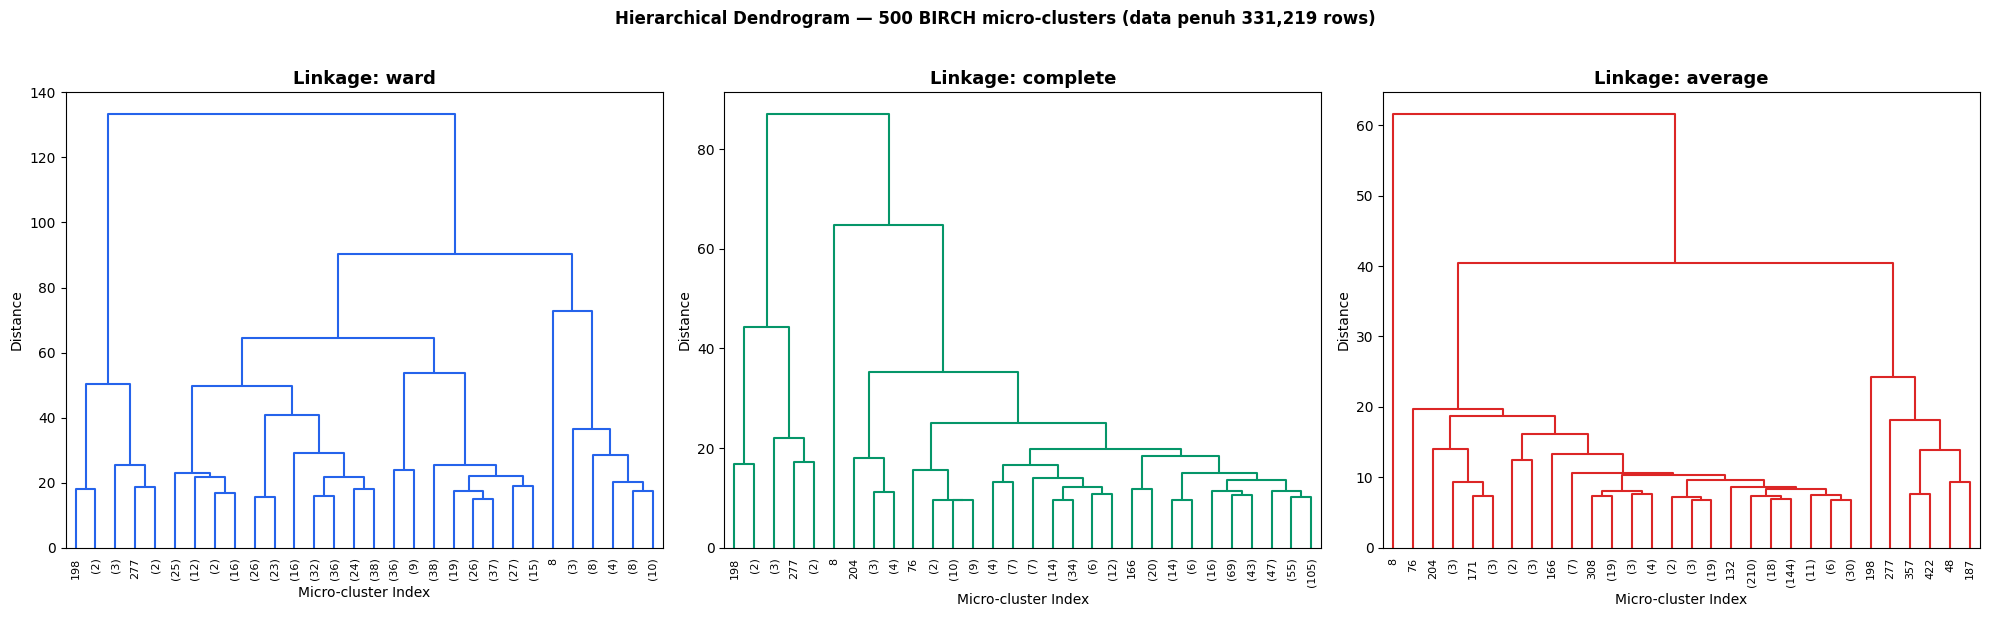

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2563EB', '#059669', '#DC2626']
for ax, method, color in zip(axes, linkage_methods, colors):
    dendrogram(linkage_results[method], ax=ax, truncate_mode='lastp', p=30,
               show_leaf_counts=True, leaf_rotation=90, leaf_font_size=8,
               color_threshold=0, above_threshold_color=color)
    ax.set_title(f'Linkage: {method}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Micro-cluster Index'); ax.set_ylabel('Distance')
plt.suptitle(f'Hierarchical Dendrogram — {len(subcenters)} BIRCH micro-clusters (data penuh {len(X_cluster):,} rows)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualisasi Scatter Plot 2D (PCA)

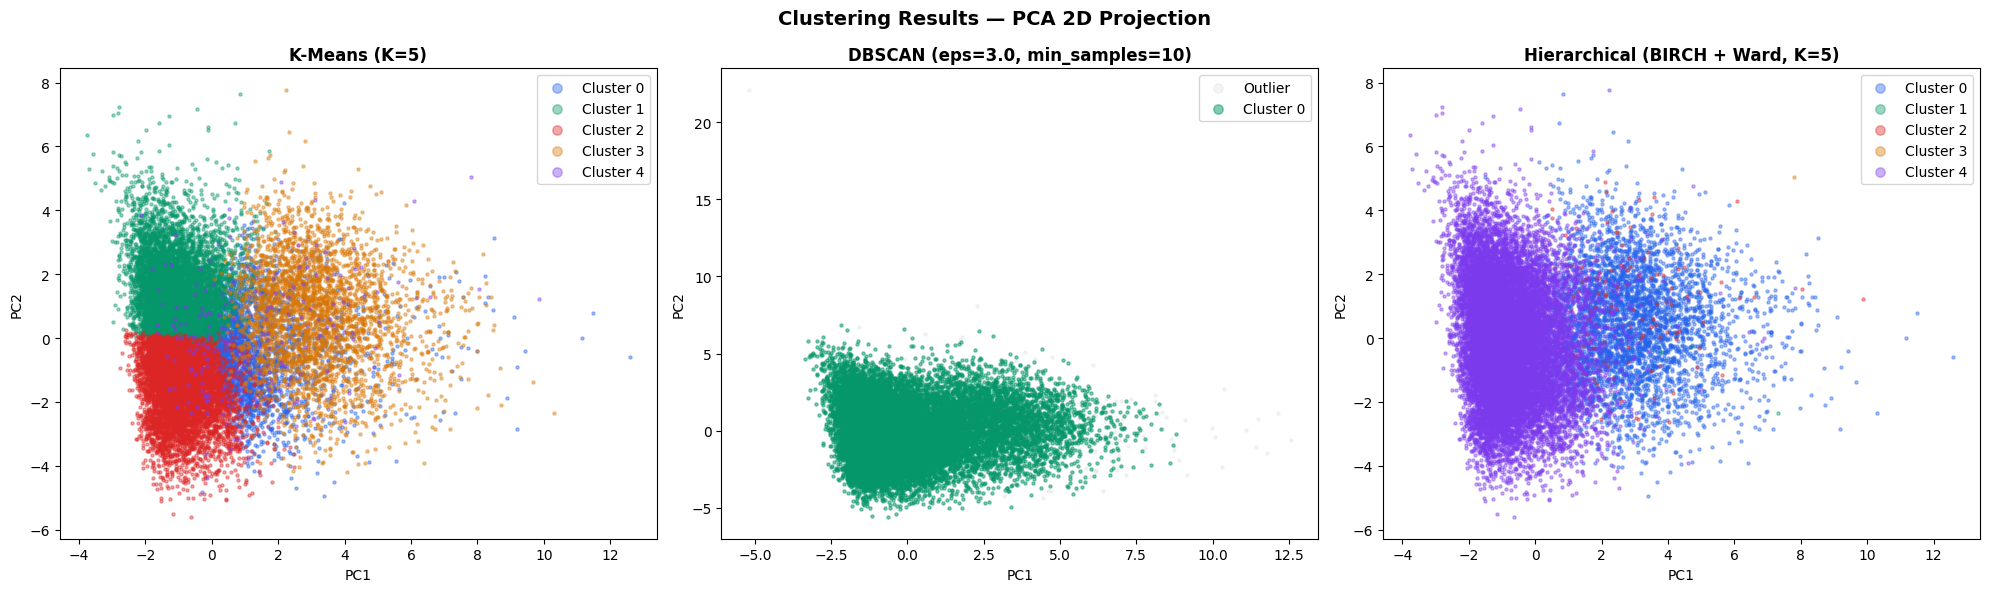

In [10]:
VIZ = 20000
rng4 = np.random.default_rng(RANDOM_SEED)
viz_idx = rng4.choice(len(X_2d), size=VIZ, replace=False)
COLORS = ['#2563EB', '#059669', '#DC2626', '#D97706', '#7C3AED']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for cid in range(K_OPTIMAL):
    mask = kmeans_labels[viz_idx] == cid
    axes[0].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[0].set_title(f'K-Means (K={K_OPTIMAL})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

viz_db_n = min(VIZ, len(dbscan_idx))
for i, lbl in enumerate(sorted(set(dbscan_labels[:viz_db_n]))):
    mask = dbscan_labels[:viz_db_n] == lbl
    name = 'Outlier' if lbl == -1 else f'Cluster {lbl}'
    color = '#CCCCCC' if lbl == -1 else COLORS[min(i, len(COLORS)-1)]
    alpha = 0.2 if lbl == -1 else 0.5
    axes[1].scatter(X_2d[dbscan_idx[:viz_db_n]][mask, 0], X_2d[dbscan_idx[:viz_db_n]][mask, 1], c=color, label=name, alpha=alpha, s=5)
axes[1].set_title(f'DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3)

for cid in range(K_OPTIMAL):
    mask = hier_labels[viz_idx] == cid
    axes[2].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[2].set_title(f'Hierarchical (BIRCH + Ward, K={K_OPTIMAL})', fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(markerscale=3)

plt.suptitle('Clustering Results — PCA 2D Projection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cluster_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Simpan Cluster Labels

In [11]:
labels_df = pd.DataFrame({
    'ROW_ID': np.arange(len(X_cluster)),
    'CLUSTER_KMEANS': kmeans_labels,
    'CLUSTER_HIER': hier_labels,
})
labels_df['CLUSTER_DBSCAN'] = np.nan
labels_df.loc[dbscan_idx, 'CLUSTER_DBSCAN'] = dbscan_labels.astype(float)
labels_df['IS_OUTLIER'] = (labels_df['CLUSTER_DBSCAN'] == -1).astype('Int8')

labels_df.to_csv(OUT_DIR / 'cluster_labels.csv', index=False)
labels_df.to_csv(PROJECT_ROOT / 'datasets/final/cluster_labels.csv', index=False)
print(f'Saved cluster_labels.csv to:')
print(f'  {OUT_DIR / "cluster_labels.csv"}')
print(f'  {PROJECT_ROOT / "datasets/final/cluster_labels.csv"}  (untuk Phase 3 & 4)')
labels_df.head()

Saved cluster_labels.csv to:
  C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering\cluster_labels.csv
  C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\datasets\final\cluster_labels.csv  (untuk Phase 3 & 4)


,ROW_ID,CLUSTER_KMEANS,CLUSTER_HIER,CLUSTER_DBSCAN,IS_OUTLIER
0,0,2,4,0.0,0
1,1,1,4,NaN,0
2,2,2,4,NaN,0
3,3,2,4,NaN,0
4,4,1,4,0.0,0


## 9. Cluster Profiling — Identifikasi Karakteristik Pembeda

Untuk setiap fitur, hitung mean per cluster lalu bandingkan dengan mean global (dinormalisasi dengan std global). Hasil dalam unit "standar deviasi × 100" — fitur dengan |deviasi| terbesar = karakteristik pembeda cluster.

In [12]:
TOP_N = 10
df_prof = pd.concat([df.reset_index(drop=True), labels_df[['CLUSTER_KMEANS']].reset_index(drop=True)], axis=1)
feat_cols = [c for c in df_prof.columns if c not in ['SK_ID_CURR', 'CLUSTER_KMEANS'] and pd.api.types.is_numeric_dtype(df_prof[c])]

profiles = df_prof.groupby('CLUSTER_KMEANS')[feat_cols].mean()
global_mean = df_prof[feat_cols].mean()
global_std = df_prof[feat_cols].std().replace(0, np.nan)
rel_diff = profiles.sub(global_mean).div(global_std) * 100

profiles.to_csv(OUT_DIR / 'cluster_profiles.csv')
print(f'Saved cluster_profiles.csv ({profiles.shape[0]} clusters × {profiles.shape[1]} features)')

summary_rows = []
top_features = {}
for cid in rel_diff.index:
    row = rel_diff.loc[cid].abs().sort_values(ascending=False)
    top_cols = row.head(TOP_N).index.tolist()
    top_df = pd.DataFrame({
        'fitur': top_cols,
        'rel_diff_pct': rel_diff.loc[cid, top_cols].values,
        'arah': ['LEBIH TINGGI' if v > 0 else 'LEBIH RENDAH' for v in rel_diff.loc[cid, top_cols].values],
    }).sort_values('rel_diff_pct', key=abs, ascending=False)
    top_features[cid] = top_df
    for _, r in top_df.iterrows():
        summary_rows.append({'cluster_id': cid, 'fitur': r['fitur'], 'rel_diff_pct': round(r['rel_diff_pct'], 2), 'arah': r['arah']})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / 'cluster_summary.csv', index=False)
print(f'Saved cluster_summary.csv')

for cid in sorted(top_features.keys()):
    n = (labels_df['CLUSTER_KMEANS'] == cid).sum()
    pct = n / len(labels_df) * 100
    print(f'\n{"="*70}\nCLUSTER {cid} — {n:,} applicants ({pct:.1f}%)\n{"-"*70}')
    for _, r in top_features[cid].iterrows():
        arrow = '▲' if r['arah'] == 'LEBIH TINGGI' else '▼'
        print(f'  {r["fitur"]:42s} {r["rel_diff_pct"]:>+7.1f}%  {arrow} {r["arah"]}')

Saved cluster_profiles.csv (5 clusters × 67 features)
Saved cluster_summary.csv

CLUSTER 0 — 44,102 applicants (13.3%)
----------------------------------------------------------------------
  PREV_COUNT                                  +153.2%  ▲ LEBIH TINGGI
  PREV_REFUSED_COUNT                          +131.9%  ▲ LEBIH TINGGI
  AMT_REQ_CREDIT_BUREAU_YEAR                  +114.8%  ▲ LEBIH TINGGI
  POS_MONTHS_COUNT                            +101.8%  ▲ LEBIH TINGGI
  PREV_APPROVAL_RATE                           -71.5%  ▼ LEBIH RENDAH
  BUREAU_COUNT                                 +51.0%  ▲ LEBIH TINGGI
  EXT_SOURCE_3                                 -33.7%  ▼ LEBIH RENDAH
  CREDIT_TO_INCOME                             -33.3%  ▼ LEBIH RENDAH
  CC_UTILIZATION_MEAN                          -30.6%  ▼ LEBIH RENDAH
  CC_UTILIZATION_MAX                           -28.8%  ▼ LEBIH RENDAH

CLUSTER 1 — 116,056 applicants (35.0%)
----------------------------------------------------------------------

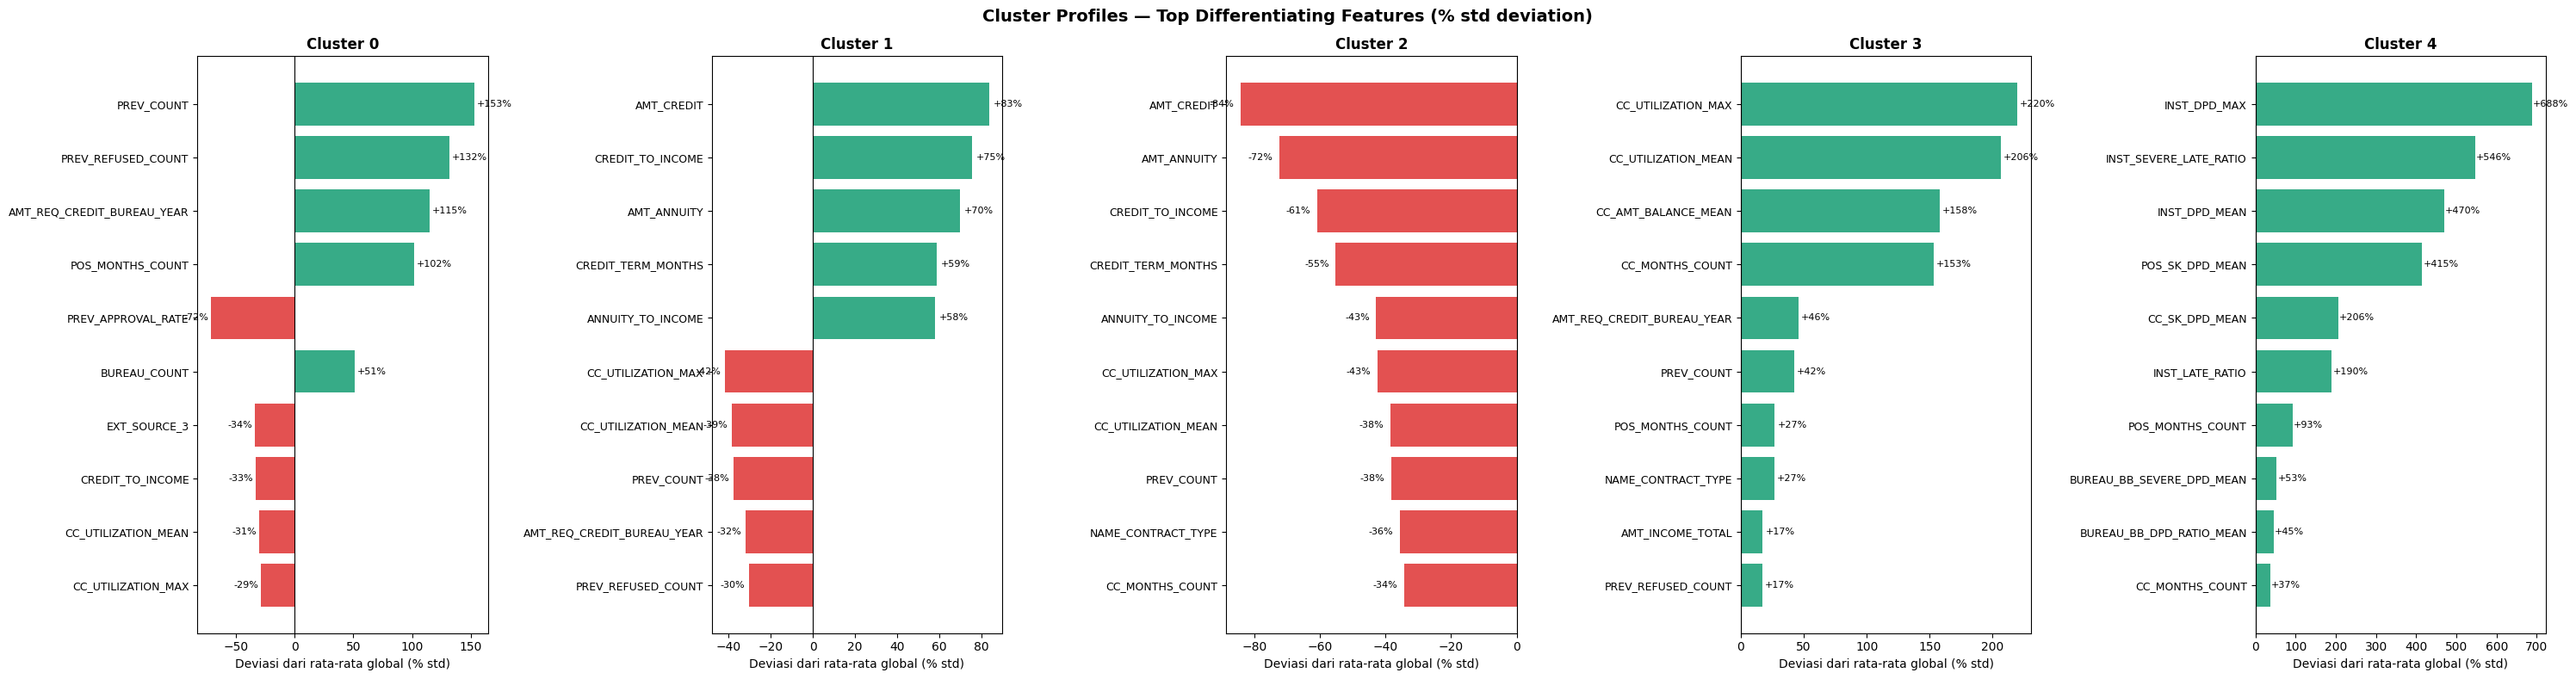

In [13]:
n_clusters = len(top_features)
fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 8))
if n_clusters == 1:
    axes = [axes]
for ax, cid in zip(axes, sorted(top_features.keys())):
    tdf = top_features[cid].head(TOP_N)
    values = tdf['rel_diff_pct'].values
    labels = tdf['fitur'].values
    colors_bar = ['#059669' if v > 0 else '#DC2626' for v in values]
    bars = ax.barh(range(len(values)), values, color=colors_bar, alpha=0.8)
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Deviasi dari rata-rata global (% std)')
    ax.set_title(f'Cluster {cid}', fontweight='bold')
    ax.invert_yaxis()
    for bar, val in zip(bars, values):
        x = val + (2 if val >= 0 else -2)
        ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=8, ha='left' if val >= 0 else 'right')
plt.suptitle('Cluster Profiles — Top Differentiating Features (% std deviation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cluster_profile_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Business Interpretation & Report

Berdasarkan profil top-10 fitur per cluster, tetapkan **nama bisnis**, **profil risiko**, dan **rekomendasi**.

Nama cluster ditetapkan oleh **manusia** (Segmentation Specialist) — algoritma hanya menemukan grouping; interpretasi adalah pekerjaan bisnis.

In [14]:
def name_cluster(cid, tdf):
    """Heuristik untuk nama cluster berdasarkan top features. Bisa di-override manual."""
    top = tdf.head(5)
    feats = ' '.join(top['fitur'].values)
    dpd_signal = top[(top['fitur'].str.contains('DPD|LATE')) & (top['rel_diff_pct'] > 100)]
    cc_high = top[(top['fitur'].str.contains('CC_UTILIZATION')) & (top['rel_diff_pct'] > 100)]
    credit_high = (top[top['fitur']=='AMT_CREDIT']['rel_diff_pct'].sum() > 30)
    credit_low = (top[top['fitur']=='AMT_CREDIT']['rel_diff_pct'].sum() < -30)
    prev_high = (top[top['fitur']=='PREV_COUNT']['rel_diff_pct'].sum() > 30)
    if len(dpd_signal) >= 2:
        return ('Peminjam Bermasalah', 'Peminjam Kronis Gagal Bayar — Profil Risiko Ekstrem', 'SANGAT TINGGI')
    if len(cc_high) >= 2:
        return ('Pengguna CC Intensif', 'Pengguna Kartu Kredit Intensif — Revolving Credit Dependent', 'SEDANG-TINGGI')
    if credit_high and not prev_high:
        return ('Peminjam Ambisius', 'Peminjam Kredit Besar — Debt-to-Income Tinggi', 'SEDANG')
    if credit_low:
        return ('Peminjam Minimal', 'Peminjam Sederhana — Berpendapatan Rendah, Kredit Kecil', 'RENDAH-SEDANG')
    if prev_high:
        return ('Veteran Aktif', 'Veteran Peminjam — Berpendapatan Tinggi, Sering Ditolak', 'SEDANG-TINGGI')
    return (f'Cluster {cid}', f'Segmen {cid}', 'SEDANG')

RECS = {
    'Peminjam Bermasalah': 'Tolak pengajuan baru atau syarat jaminan ketat. Aktifkan restrukturisasi hutang nasabah existing. Lakukan debt collection intensif. Flag sebagai high-risk monitoring prioritas.',
    'Pengguna CC Intensif': 'Monitor utilisasi CC berkala. Tawarkan produk konsolidasi hutang. Batasi peningkatan limit kredit sampai utilisasi turun di bawah 70%.',
    'Peminjam Ambisius': 'Verifikasi stabilitas pendapatan sebelum persetujuan. Ideal untuk KPR/kendaraan. Stress-test kemampuan bayar pada skenario pendapatan turun 20-30%. Pertimbangkan asuransi jiwa/kesehatan sebagai syarat.',
    'Peminjam Minimal': 'Segmen ideal micro-credit atau multiguna kecil. Prioritaskan edukasi keuangan & program inklusi. Pemantauan ringan cukup memadai.',
    'Veteran Aktif': 'Evaluasi alasan penolakan historis. Cocok untuk kredit berjaminan (mortgage) mengingat pendapatan tinggi. Verifikasi debt-to-income ratio ketat.',
}

cluster_meta = {}
for cid, tdf in top_features.items():
    nama, nama_lengkap, risiko = name_cluster(cid, tdf)
    cluster_meta[cid] = {
        'nama': nama,
        'nama_lengkap': nama_lengkap,
        'profil_risiko': risiko,
        'rekomendasi': RECS.get(nama, 'Evaluasi case-by-case.'),
        'karakteristik': [
            f"{r['fitur']} {r['rel_diff_pct']:+.1f}% ({r['arah']})"
            for _, r in tdf.iterrows()
        ],
    }
    print(f'Cluster {cid}: "{nama}" — Risk: {risiko}')

Cluster 0: "Veteran Aktif" — Risk: SEDANG-TINGGI
Cluster 1: "Peminjam Ambisius" — Risk: SEDANG
Cluster 2: "Peminjam Minimal" — Risk: RENDAH-SEDANG
Cluster 3: "Pengguna CC Intensif" — Risk: SEDANG-TINGGI
Cluster 4: "Peminjam Bermasalah" — Risk: SANGAT TINGGI


In [15]:
INTERPRETASI = {
    'Peminjam Bermasalah': 'Kelompok kecil namun profil risiko ekstrem. Days Past Due (DPD) berlipat ganda di multiple produk (installment, POS, CC) — pola gagal bayar kronis dan sistemik, bukan keterlambatan insidental. Mereka sudah dalam kondisi financial distress serius.',
    'Pengguna CC Intensif': 'Sangat bergantung pada revolving credit (kartu kredit). Utilisasi CC jauh di atas rata-rata dengan saldo besar menunjukkan penggunaan mendekati atau melampaui limit. Riwayat CC panjang = nasabah lama yang aktif. Risiko: jika pendapatan terganggu, default berantai di banyak produk sekaligus.',
    'Peminjam Ambisius': 'Mengajukan pinjaman besar relatif terhadap pendapatan dengan tenor panjang. Sedikit riwayat pengajuan sebelumnya + utilisasi CC rendah menandakan peminjam pertama kali. Debt-to-income tinggi adalah risiko utama: rentan terhadap guncangan pendapatan.',
    'Peminjam Minimal': 'Peminjam berpendapatan rendah dengan kebutuhan kredit minimal. Pinjaman kecil tenor pendek — kemungkinan konsumsi sehari-hari atau darurat. Tidak aktif CC menunjukkan keterbatasan akses produk keuangan. Exposure kecil = risiko rendah, namun kapasitas bayar terbatas saat ada guncangan.',
    'Veteran Aktif': 'Peminjam berpengalaman dengan pendapatan tinggi yang aktif & agresif mencari kredit. Meski pendapatan tinggi sering ditolak — kemungkinan rasio hutang-terhadap-kredit bermasalah atau over-application. Utilisasi CC rendah = mengelola CC dengan baik, namun histori penolakan tinggi = profil risiko perlu diperhatikan.',
}

RISK_BADGE = {
    'SANGAT TINGGI': '🔴 SANGAT TINGGI',
    'SEDANG-TINGGI': '🟠 SEDANG-TINGGI',
    'SEDANG': '🟡 SEDANG',
    'RENDAH-SEDANG': '🟢 RENDAH-SEDANG',
}

def parse_karakteristik(k_str):
    # Format: "FITUR_NAME +/-X.X% (LEBIH TINGGI/RENDAH)"
    # Split on " (" to separate feature+value from direction
    if ' (' in k_str:
        left, right = k_str.rsplit(' (', 1)
        arah = right.rstrip(')')
        icon = '▲' if 'TINGGI' in arah else '▼'
        return left, f'{icon} {arah}'
    return k_str, ''

def build_report():
    lines = []
    lines.append('# Phase 2 — Segmentation via Clustering')
    lines.append('**Dataset:** Home Credit Default Risk')
    lines.append('')
    lines.append('---')
    lines.append('')

    lines.append('## Ringkasan Eksekutif')
    lines.append('')
    lines.append('| Metrik | Nilai |')
    lines.append('|--------|-------|')
    lines.append(f'| Total applicants | {len(labels_df):,} |')
    lines.append(f'| Jumlah cluster | {K_OPTIMAL} (K-Means) |')
    lines.append(f'| Komponen PCA | {N_PCA_CLUSTER} ({cumvar[N_PCA_CLUSTER-1]*100:.1f}% variance) |')
    lines.append(f'| Silhouette Score | {sil_kmeans:.4f} |')
    lines.append(f'| Inertia (K-Means) | {kmeans.inertia_:,.1f} |')
    lines.append(f'| K dari Elbow Method | {elbow_k} |')
    lines.append(f'| K dari Silhouette | {best_sil_k} |')
    lines.append('')
    lines.append('**Algoritma dijalankan:**')
    lines.append('')
    lines.append('1. **K-Means** — full data, K=5 (segmentasi utama)')
    lines.append(f'2. **DBSCAN** — sample 30K, `eps={EPS}`, `min_samples={MIN_SAMPLES}` (outlier detection)')
    lines.append(f'3. **Hierarchical** — BIRCH ({len(subcenters)} micro-clusters) + Ward linkage')
    lines.append('')

    lines.append('## Distribusi Cluster K-Means')
    lines.append('')
    lines.append('| Cluster | Nama | Jumlah | Persentase | Profil Risiko |')
    lines.append('|---------|------|--------|------------|---------------|')
    for cid in sorted(np.unique(kmeans_labels)):
        n = int(np.sum(kmeans_labels == cid))
        pct = n/len(kmeans_labels)*100
        meta = cluster_meta[cid]
        badge = RISK_BADGE.get(meta['profil_risiko'], meta['profil_risiko'])
        lines.append(f'| {cid} | **{meta["nama"]}** | {n:,} | {pct:.1f}% | {badge} |')
    lines.append('')
    lines.append('---')
    lines.append('')

    for cid in sorted(cluster_meta.keys()):
        meta = cluster_meta[cid]
        n = int(np.sum(kmeans_labels == cid))
        pct = n/len(kmeans_labels)*100
        badge = RISK_BADGE.get(meta['profil_risiko'], meta['profil_risiko'])
        lines.append(f'## Cluster {cid} — {meta["nama"]}')
        lines.append('')
        lines.append(f'> **{meta["nama_lengkap"]}**  ')
        lines.append(f'> {n:,} applicants ({pct:.1f}%) | Profil Risiko: {badge}')
        lines.append('')
        lines.append('### Karakteristik Utama')
        lines.append('')
        lines.append('| Fitur & Nilai | Arah |')
        lines.append('|---------------|------|')
        for k in meta['karakteristik']:
            feat_val, arah_icon = parse_karakteristik(k)
            lines.append(f'| `{feat_val}` | {arah_icon} |')
        lines.append('')
        lines.append('### Interpretasi Bisnis')
        lines.append('')
        lines.append(INTERPRETASI.get(meta['nama'], 'Profil khas tersendiri — analisis lebih lanjut diperlukan.'))
        lines.append('')
        lines.append('### Rekomendasi')
        lines.append('')
        lines.append(f'> {meta["rekomendasi"]}')
        lines.append('')
        lines.append('---')
        lines.append('')

    lines.append('## Data Mining Concepts — Phase 2')
    lines.append('')
    lines.append('### 1. Unsupervised Pattern Discovery')
    lines.append('Tidak ada label TARGET digunakan saat training. Algoritma menemukan grouping dari struktur 67 fitur behavioral saja.')
    lines.append('')
    lines.append('### 2. Distance Metrics')
    lines.append(f'- **K-Means**: Euclidean distance di ruang PCA {N_PCA_CLUSTER}-komponen (curse-of-dim teratasi).')
    lines.append(f'- **DBSCAN**: `eps={EPS}` = radius neighborhood; `min_samples={MIN_SAMPLES}` = density threshold.')
    lines.append('')
    lines.append('### 3. Cluster Validity Indices')
    lines.append('')
    lines.append('| Indeks | Nilai | Keterangan |')
    lines.append('|--------|-------|------------|')
    lines.append(f'| Silhouette Score | {sil_kmeans:.4f} | Wajar untuk financial data berdimensi tinggi |')
    lines.append(f'| Inertia (WCSS) | {kmeans.inertia_:,.1f} | Total within-cluster sum of squares |')
    lines.append(f'| Elbow Method | K = {elbow_k} | Titik penurunan inertia melambat |')
    lines.append(f'| Silhouette peak | K = {best_sil_k} | K = {K_OPTIMAL} dipilih untuk granularitas bisnis |')
    lines.append('')
    lines.append('### 4. Dendrogram Analysis')
    lines.append(f'Ward / Complete / Average linkage pada **{len(subcenters)} BIRCH micro-cluster centroids**.')
    lines.append(f'Ketiga metode konsisten menunjukkan struktur {K_OPTIMAL} cluster, memvalidasi pilihan K.')
    lines.append('')

    return '\n'.join(lines)

report = build_report()
report_path = OUT_DIR / 'business_report.md'
report_path.write_text(report, encoding='utf-8')
print(f'Saved {report_path}')
print()
print(report[:2500])

Saved C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering\business_report.md

# Phase 2 — Segmentation via Clustering
**Dataset:** Home Credit Default Risk

---

## Ringkasan Eksekutif

| Metrik | Nilai |
|--------|-------|
| Total applicants | 331,219 |
| Jumlah cluster | 5 (K-Means) |
| Komponen PCA | 10 (54.4% variance) |
| Silhouette Score | 0.1492 |
| Inertia (K-Means) | 4,788,055.5 |
| K dari Elbow Method | 5 |
| K dari Silhouette | 2 |

**Algoritma dijalankan:**

1. **K-Means** — full data, K=5 (segmentasi utama)
2. **DBSCAN** — sample 30K, `eps=3.0`, `min_samples=10` (outlier detection)
3. **Hierarchical** — BIRCH (500 micro-clusters) + Ward linkage

## Distribusi Cluster K-Means

| Cluster | Nama | Jumlah | Persentase | Profil Risiko |
|---------|------|--------|------------|---------------|
| 0 | **Veteran Aktif** | 44,102 | 13.3% | 🟠 SEDANG-TINGGI |
| 1 | **Peminjam Ambisius** | 116,056 | 35.0% | 🟡 SEDANG |
| 2 | **Peminjam Minimal** |

---
**Phase 2 selesai.** Output:
- `results/phase2_clustering/` — semua artefak
- `datasets/final/cluster_labels.csv` — diteruskan ke Phase 3 & 4